# Activity 2: Analyzing Different Scenarios and Generating the Appropriate Visualization

We'll be working with the 120 years of Olympic History dataset acquired by Randi Griffin from https://www.sports-reference.com/ and made available on the GitHub repository of this book. Your assignment is to identify the top five sports based on the largest number of medals awarded in the year 2016, and then perform the following analysis:

1.  Generate a plot indicating the number of medals awarded in each of the top five sports in 2016.
2.  Plot a graph depicting the distribution of the age of medal winners in the top five sports in 2016.
3.  Find out which national teams won the largest number of medals in the top five sports in 2016.
4.  Observe the trend in the average weight of male and female athletes winning in the top five sports in 2016.

## High-Level Steps

1.  Download the dataset and format it as a pandas DataFrame.
2.  Filter the DataFrame to only include the rows corresponding to medal winners from 2016.
3.  Find out the medals awarded in 2016 for each sport.
4.  List the top five sports based on the largest number of medals awarded. Filter the DataFrame one more time to only include the records for the top five sports in 2016.
5.  Generate a bar plot of record counts corresponding to each of the top five sports.
6.  Generate a histogram for the Age feature of all medal winners in the top five sports (2016).
7.  Generate a bar plot indicating how many medals were won by each country's team in the top five sports in 2016.
8.  Generate a bar plot indicating the average weight of players, categorized based on gender, winning in the top five sports in 2016.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Load the dataset ──────────────────────────────────────────────────────
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2021/2021-07-27/olympics.csv"
df = pd.read_csv(url)
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (271116, 15)


,id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [2]:
# ── 2. Filter for 2016 medal winners ────────────────────────────────────────
df_2016_medals = df[(df['year'] == 2016) & (df['medal'].notna())]
print(f"Medal winners in 2016: {len(df_2016_medals)}")

# ── 3. Top 5 sports by medal count ──────────────────────────────────────────
sport_medal_counts = df_2016_medals['sport'].value_counts().head(5)
top5_sports = sport_medal_counts.index.tolist()
print("Top 5 sports by medals in 2016:", top5_sports)

# Filter to top 5 sports only
df_top5 = df_2016_medals[df_2016_medals['sport'].isin(top5_sports)]
df_top5.head()


Medal winners in 2016: 2023
Top 5 sports by medals in 2016: ['Athletics', 'Swimming', 'Rowing', 'Football', 'Hockey']


,id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal
158,62,Giovanni Abagnale,M,21.0,198.0,90.0,Italy,ITA,2016 Summer,2016,Summer,Rio de Janeiro,Rowing,Rowing Men's Coxless Pairs,Bronze
814,465,"Matthew ""Matt"" Abood",M,30.0,197.0,92.0,Australia,AUS,2016 Summer,2016,Summer,Rio de Janeiro,Swimming,Swimming Men's 4 x 100 metres Freestyle Relay,Bronze
1228,690,Chantal Achterberg,F,31.0,172.0,72.0,Netherlands,NED,2016 Summer,2016,Summer,Rio de Janeiro,Rowing,Rowing Women's Quadruple Sculls,Silver
1529,846,Valerie Kasanita Adams-Vili (-Price),F,31.0,193.0,120.0,New Zealand,NZL,2016 Summer,2016,Summer,Rio de Janeiro,Athletics,Athletics Women's Shot Put,Silver
1847,1017,Nathan Ghar-Jun Adrian,M,27.0,198.0,100.0,United States,USA,2016 Summer,2016,Summer,Rio de Janeiro,Swimming,Swimming Men's 50 metres Freestyle,Bronze


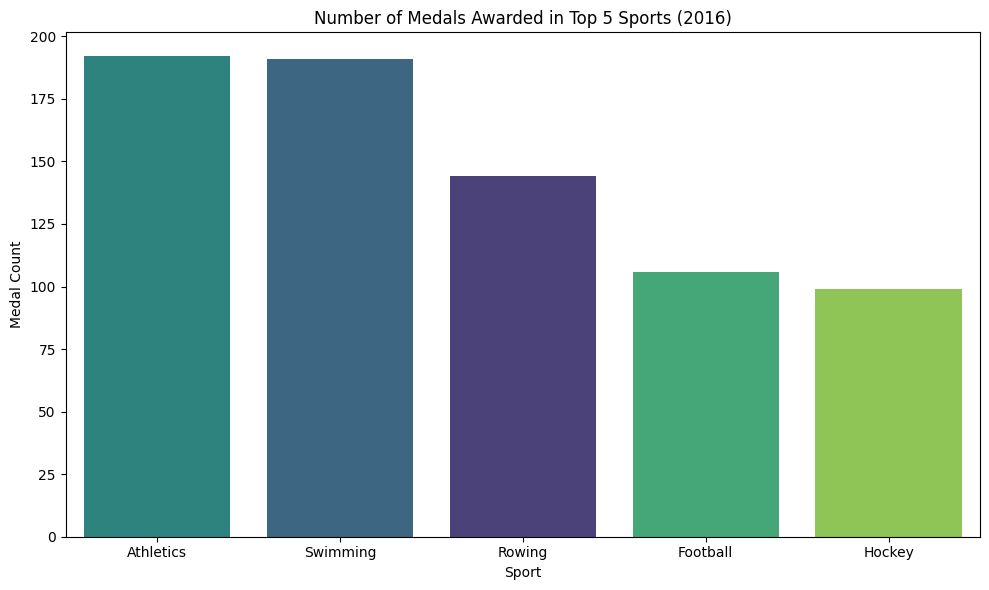

In [4]:
# ── Plot 1: Medal count per sport (top 5) ───────────────────────────────────
plt.figure(figsize=(10, 6))
sns.countplot(data=df_top5, x='sport', hue='sport', order=top5_sports, palette='viridis', legend=False)
plt.title('Number of Medals Awarded in Top 5 Sports (2016)')
plt.xlabel('Sport')
plt.ylabel('Medal Count')
plt.tight_layout()
plt.show()


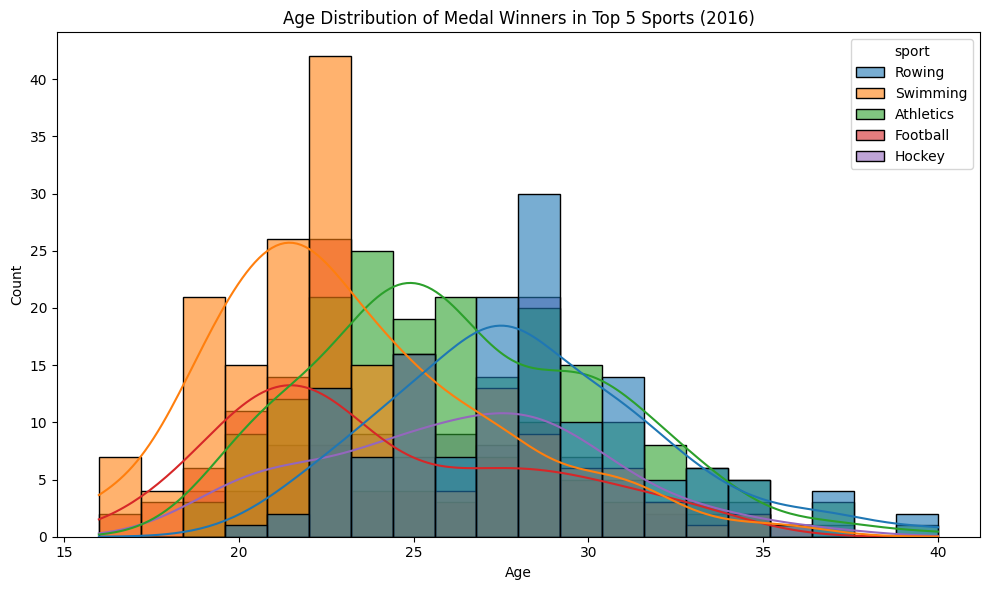

In [5]:
# ── Plot 2: Age distribution of medal winners in top 5 sports ───────────────
plt.figure(figsize=(10, 6))
sns.histplot(data=df_top5, x='age', hue='sport', kde=True, bins=20, alpha=0.6)
plt.title('Age Distribution of Medal Winners in Top 5 Sports (2016)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


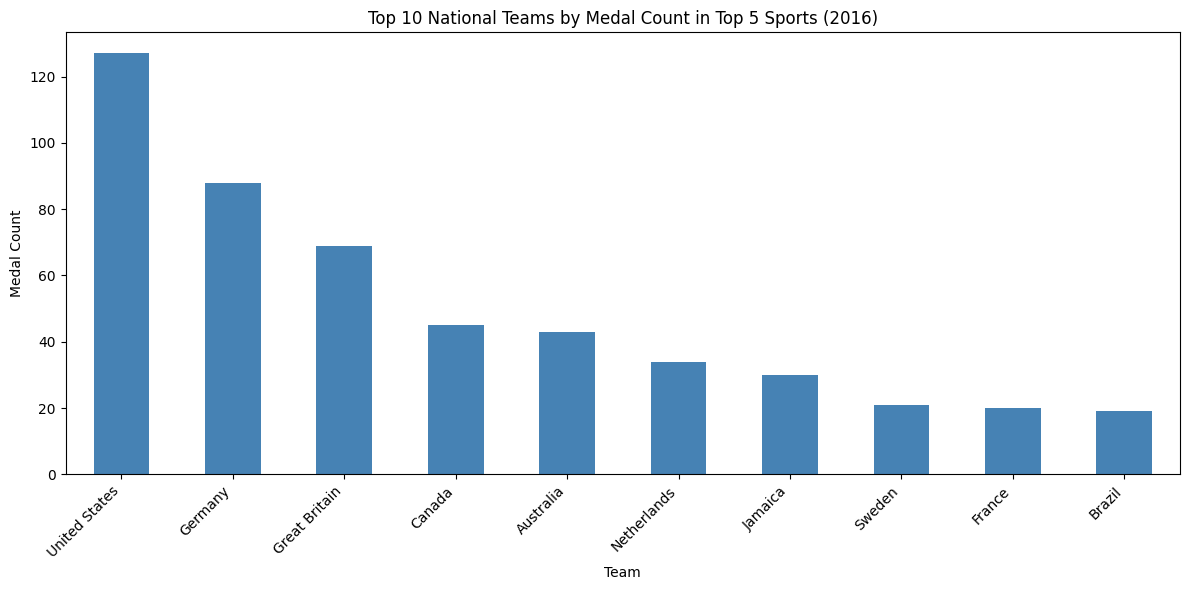

In [6]:
# ── Plot 3: Top national teams by medal count in top 5 sports ───────────────
top_teams = df_top5['team'].value_counts().head(10)
plt.figure(figsize=(12, 6))
top_teams.plot(kind='bar', color='steelblue')
plt.title('Top 10 National Teams by Medal Count in Top 5 Sports (2016)')
plt.xlabel('Team')
plt.ylabel('Medal Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


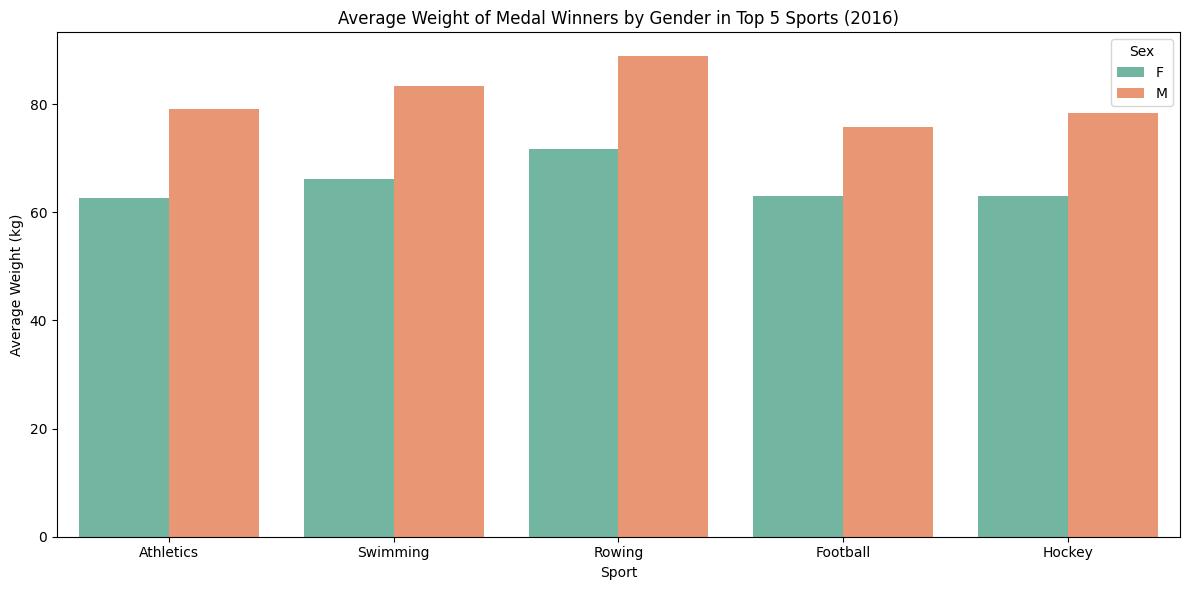

In [7]:
# ── Plot 4: Average weight of athletes by gender in top 5 sports ────────────
avg_weight = df_top5.groupby(['sport', 'sex'])['weight'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_weight, x='sport', y='weight', hue='sex', order=top5_sports, palette='Set2')
plt.title('Average Weight of Medal Winners by Gender in Top 5 Sports (2016)')
plt.xlabel('Sport')
plt.ylabel('Average Weight (kg)')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()
